# Cấu hình hiển thị dữ liệu

In [ ]:
import pandas as pd

# Thiết lập hiển thị đầy đủ các cột
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("Đã cấu hình hiển thị toàn bộ cột.")

Đã cấu hình hiển thị toàn bộ cột.


# Import thư viện phân tích

In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Kết hợp dữ liệu cộng đồng

In [ ]:
df_comm = pd.read_csv('/content/drive/MyDrive/social_network_analysis/data/community/df_community_grouped.csv')
df_meta = pd.read_csv('/content/drive/MyDrive/social_network_analysis/data/graph_information/final_merged_data.csv')

df_comm['Node'] = df_comm['Node'].apply(ast.literal_eval)

df_comm_exploded = df_comm.explode('Node').rename(columns={'Node': 'product_id', 'Community': 'Community_ID'})

df_comm_exploded['product_id'] = df_comm_exploded['product_id'].astype(int)
df_meta['product_id'] = df_meta['product_id'].astype(int)

df_merged = pd.merge(df_comm_exploded, df_meta, on='product_id', how='inner')
print(f"Gộp thành công! Bảng dữ liệu có {df_merged.shape[0]:,} dòng sẵn sàng để tổng hợp.")

Gộp thành công! Bảng dữ liệu có 120,738 dòng sẵn sàng để tổng hợp.


# Trích xuất đặc trưng cộng đồng

In [ ]:
agg_funcs = {
    'product_id': 'count',
    'Density': 'mean',   # sửa từ first -> mean
    'in_degree': 'mean',
    'out_degree': 'mean',
    'total_degree': 'mean',
    'salesrank': lambda x: x[x > 0].mean() if len(x[x > 0]) > 0 else 0,
    'similar': 'mean',
    'category_type_count': 'mean',
    'total_reviews': 'mean',
    'downloaded': 'mean',
    'avg_rating': lambda x: x[x > 0].mean() if len(x[x > 0]) > 0 else 0
}

# Thống kê đặc trưng cộng đồng
df_agg = df_merged.groupby('Community_ID').agg(agg_funcs).rename(columns={
    'product_id': 'total_product',
    'Density': 'avg_density',
    'in_degree': 'avg_indegree',
    'out_degree': 'avg_outdegree',
    'total_degree': 'avg_totaldegree',
    'salesrank': 'avg_salesrank',
    'similar': 'avg_similar',
    'category_type_count': 'avg_categorytypecount',
    'total_reviews': 'avg_totalreviews',
    'downloaded': 'avg_downloaded',
    'avg_rating': 'avg_rating'
})

# Count theo Group
group_count = (
    df_merged.groupby(['Community_ID', 'group'])
    .size()
    .unstack(fill_value=0)
    .add_prefix('count_')
)

# Count theo Node Type
node_count = (
    df_merged.groupby(['Community_ID', 'node_type'])
    .size()
    .unstack(fill_value=0)
    .add_prefix('count_')
)

# Gộp lại
df_community_features = (
    pd.concat([df_agg, group_count, node_count], axis=1)
    .reset_index()
    .fillna(0)
)

print(f"✅ Đã tạo xong DataFrame cho {len(df_community_features)} cộng đồng!")
display(df_community_features.head())

✅ Đã tạo xong DataFrame cho 565 cộng đồng!


,Community_ID,total_product,avg_density,avg_indegree,avg_outdegree,avg_totaldegree,avg_salesrank,avg_similar,avg_categorytypecount,avg_totalreviews,avg_downloaded,avg_rating,count_Book,count_DVD,count_Music,count_Software,count_Toy,count_Unknown,count_Video,count_Video Games,count_Hub,count_Normal,count_Super Hub
0,0,2474,0.001334,5.672595,4.997171,10.669766,486922.082034,3.210590,4.578416,13.745756,13.505255,4.334847,1763,78,453,0,0,34,146,0,281,2193,0
1,1,996,0.003361,5.588353,4.994980,10.583333,499059.525941,3.242972,4.772088,14.673695,14.229920,4.332168,717,34,184,0,0,13,48,0,82,914,0
2,2,33,0.107955,5.606061,5.000000,10.606061,534124.090909,3.575758,4.121212,11.121212,10.878788,4.190476,22,0,9,0,0,0,2,0,1,32,0
3,3,596,0.005417,5.414430,4.998322,10.412752,540447.757216,3.192953,4.471477,14.052013,13.954698,4.321867,454,16,104,0,0,5,17,0,31,565,0
4,4,3072,0.001112,5.889648,4.995443,10.885091,478793.765692,3.262044,4.706055,13.558919,13.487956,4.331843,2154,114,620,0,0,25,159,0,671,2401,0


# Chuẩn hóa dữ liệu

In [ ]:
features = df_community_features.drop(columns=['Community_ID'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Tìm số cụm tối ưu

Đang chạy kiểm tra Silhouette Score (từ K=2 đến K=8)...
 - K=2: Silhouette Score = 0.5770
 - K=3: Silhouette Score = 0.3538
 - K=4: Silhouette Score = 0.2208
 - K=5: Silhouette Score = 0.2276
 - K=6: Silhouette Score = 0.2361
 - K=7: Silhouette Score = 0.2279
 - K=8: Silhouette Score = 0.1976
 - K=9: Silhouette Score = 0.1877
 - K=10: Silhouette Score = 0.1957
 - K=11: Silhouette Score = 0.1689
 - K=12: Silhouette Score = 0.1810
 - K=13: Silhouette Score = 0.1730
 - K=14: Silhouette Score = 0.1913
 - K=15: Silhouette Score = 0.1879


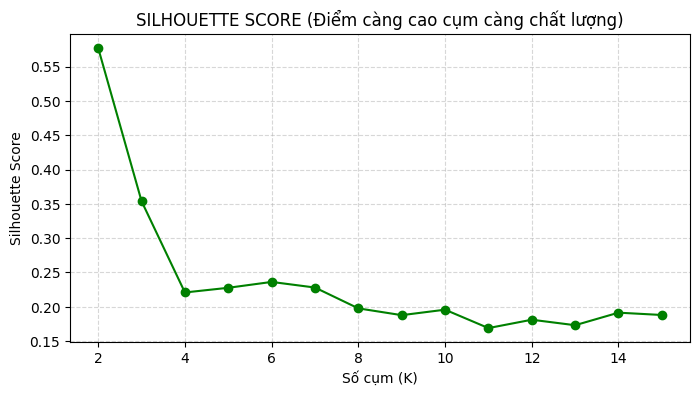

In [ ]:
from sklearn.metrics import silhouette_score

print("Đang chạy kiểm tra Silhouette Score (từ K=2 đến K=8)...")
sil_scores = []
K_test_range = range(2, 16)

for k in K_test_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=10000, random_state=42)
    sil_scores.append(score)
    print(f" - K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(K_test_range, sil_scores, marker='o', color='green')
plt.title('SILHOUETTE SCORE (Điểm càng cao cụm càng chất lượng)')
plt.xlabel('Số cụm (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Phân cụm bằng K-Means

In [ ]:
import os
import pandas as pd
from sklearn.cluster import KMeans
from IPython.display import display

print("="*60)
print("BƯỚC 4: PHÂN CỤM K-MEANS & XUẤT PROFILE CHI TIẾT CÁC CỤM")
print("="*60)

OPTIMAL_K = 4

export_dir = "/content/drive/MyDrive/social_network_analysis/data/community_analysis"
os.makedirs(export_dir, exist_ok=True)

output_file = os.path.join(export_dir, "df_community_analysis.csv")
profile_summary_file = os.path.join(export_dir, "cluster_profiling_summary.csv")

# =========================
# K-MEANS
# =========================
print(f"Đang chạy K-Means với K={OPTIMAL_K}...")

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

df_community_features["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)

df_community_features.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"ĐÃ LƯU FILE KẾT QUẢ:\n -> {output_file}")

# =========================
# PROFILING
# =========================
print("\nĐang thống kê đặc trưng các cụm...")

profiling_cols = [
    'total_product',
    'avg_density',
    'avg_indegree',
    'avg_outdegree',
    'avg_totaldegree',
    'avg_salesrank',
    'avg_rating',
    'avg_totalreviews',
    'avg_similar',
    'avg_categorytypecount',
    'avg_downloaded'
]

# Tự động lấy tất cả count group + count node type
count_cols = [
    col for col in df_community_features.columns
    if col.startswith('count_')
]

profiling_cols.extend(count_cols)

cluster_profile = (
    df_community_features
    .groupby('KMeans_Cluster')[profiling_cols]
    .mean()
)

# Làm tròn
for col in cluster_profile.columns:
    if col == 'avg_density':
        cluster_profile[col] = cluster_profile[col].round(4)
    else:
        cluster_profile[col] = cluster_profile[col].round(2)

# số community trong mỗi cluster
cluster_profile.insert(
    0,
    'Communities',
    df_community_features.groupby('KMeans_Cluster').size()
)

# đổi tên index
cluster_profile.index = [
    f'Cụm {i+1}'
    for i in cluster_profile.index
]

# sắp xếp theo sales rank
cluster_profile_sorted = cluster_profile.sort_values(
    by='avg_salesrank'
)

cluster_profile_sorted.to_csv(
    profile_summary_file,
    encoding='utf-8-sig'
)

print(f"ĐÃ XUẤT PROFILE:\n -> {profile_summary_file}")

print("\nBẢNG CHÂN DUNG CÁC CỤM:")
display(cluster_profile_sorted)

BƯỚC 4: PHÂN CỤM K-MEANS & XUẤT PROFILE CHI TIẾT CÁC CỤM
Đang chạy K-Means với K=4...
ĐÃ LƯU FILE KẾT QUẢ:
 -> /content/drive/MyDrive/social_network_analysis/data/community_analysis/df_community_analysis.csv

Đang thống kê đặc trưng các cụm...
ĐÃ XUẤT PROFILE:
 -> /content/drive/MyDrive/social_network_analysis/data/community_analysis/cluster_profiling_summary.csv

BẢNG CHÂN DUNG CÁC CỤM:


,Communities,total_product,avg_density,avg_indegree,avg_outdegree,avg_totaldegree,avg_salesrank,avg_rating,avg_totalreviews,avg_similar,avg_categorytypecount,avg_downloaded,count_Book,count_DVD,count_Music,count_Software,count_Toy,count_Unknown,count_Video,count_Video Games,count_Hub,count_Normal,count_Super Hub
Cụm 3,385,51.84,0.2789,5.48,4.99,10.47,461745.72,4.32,16.10,3.36,4.72,16.03,37.29,1.96,9.67,0.00,0.00,0.55,2.38,0.00,2.38,49.47,0.00
Cụm 4,14,2865.07,0.0013,6.27,5.00,11.27,493550.12,4.32,13.90,3.24,4.58,13.68,2045.64,101.36,545.71,0.00,0.07,31.64,140.57,0.07,878.86,1973.71,12.50
Cụm 2,60,978.62,0.0040,6.00,5.00,11.00,500140.43,4.32,14.04,3.24,4.60,13.81,704.40,35.75,179.32,0.02,0.02,11.43,47.68,0.00,134.00,844.45,0.17
Cụm 1,106,18.40,0.4168,6.56,5.00,11.56,640274.67,4.31,10.45,2.85,4.22,10.44,13.55,0.68,3.22,0.00,0.00,0.23,0.73,0.00,3.92,14.45,0.02


# Trực quan hóa kết quả phân cụm

Đang tính toán giảm chiều dữ liệu bằng PCA...
Thành phần chính 1 giải thích được: 36.12% dữ liệu.
Thành phần chính 2 giải thích được: 9.72% dữ liệu.
Đang render biểu đồ không gian phân cụm...


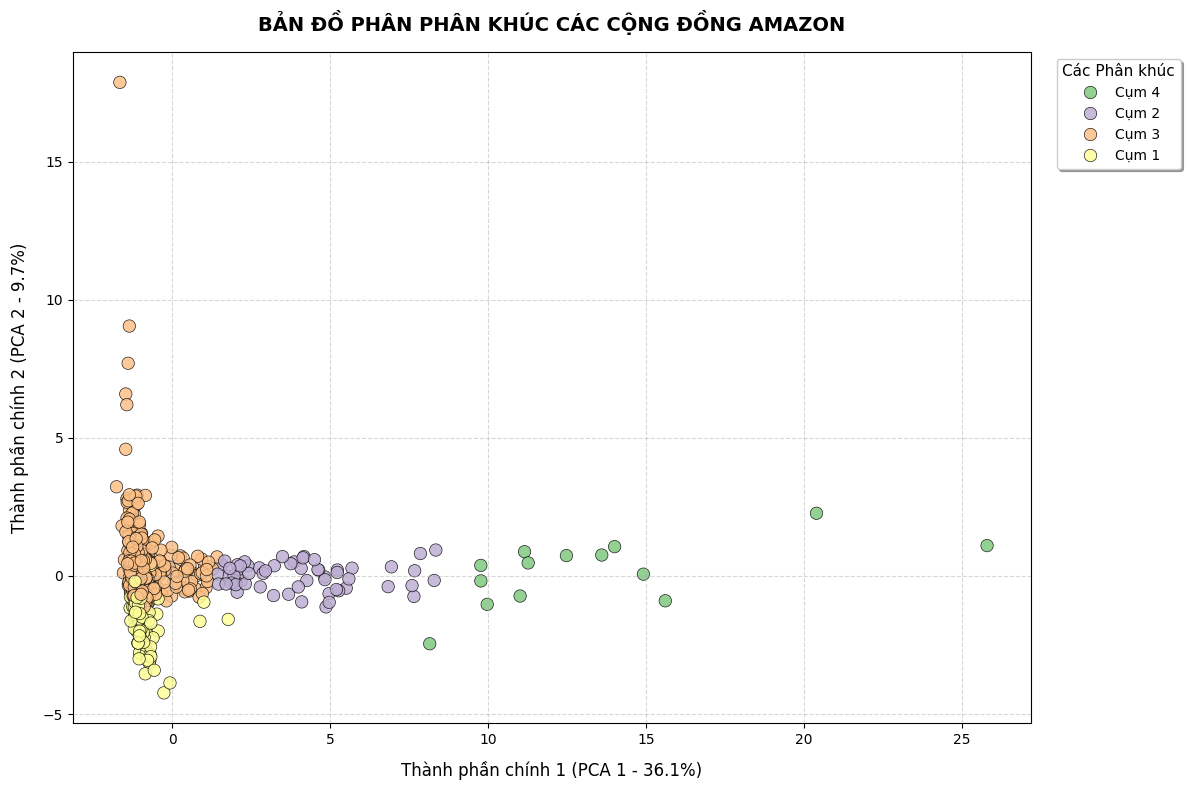

HOÀN TẤT! Biểu đồ phân cụm sắc nét đã được lưu an toàn tại:
   -> '/content/drive/MyDrive/social_network_analysis/asset/kmeans_clusters_visualization.png'


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

export_dir = "/content/drive/MyDrive/social_network_analysis/asset"
os.makedirs(export_dir, exist_ok=True)
plot_output_path = os.path.join(export_dir, 'kmeans_clusters_visualization.png')

print("Đang tính toán giảm chiều dữ liệu bằng PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PCA_Component_1', 'PCA_Component_2'])
df_pca['Cluster'] = df_community_features['KMeans_Cluster'].apply(lambda x: f"Cụm {x+1}")

var_exp = pca.explained_variance_ratio_ * 100
print(f"Thành phần chính 1 giải thích được: {var_exp[0]:.2f}% dữ liệu.")
print(f"Thành phần chính 2 giải thích được: {var_exp[1]:.2f}% dữ liệu.")

print("Đang render biểu đồ không gian phân cụm...")
plt.figure(figsize=(12, 8), facecolor='white')

sns.scatterplot(
    x='PCA_Component_1',
    y='PCA_Component_2',
    hue='Cluster',
    data=df_pca,
    palette='Accent',
    s=80,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

plt.title('BẢN ĐỒ PHÂN PHÂN KHÚC CÁC CỘNG ĐỒNG AMAZON',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel(f'Thành phần chính 1 (PCA 1 - {var_exp[0]:.1f}%)', fontsize=12, labelpad=10)
plt.ylabel(f'Thành phần chính 2 (PCA 2 - {var_exp[1]:.1f}%)', fontsize=12, labelpad=10)

plt.legend(title='Các Phân khúc', title_fontsize='11',
           bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(plot_output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"HOÀN TẤT! Biểu đồ phân cụm sắc nét đã được lưu an toàn tại:\n   -> '{plot_output_path}'")